In [2]:
import os
import cv2
import numpy as np

DATA_DIR = "/Users/samreddyvarunreddy/Desktop/datamining/Dataset"

def load_image_paths(data_dir):
    image_paths = []
    labels = []
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(('.png')):
                full_path = os.path.join(class_path, file_name)
                image_paths.append(full_path)
                labels.append(class_name)

    return np.array(image_paths), np.array(labels)

image_paths, labels = load_image_paths(DATA_DIR)

print(f"Total images loaded: {len(image_paths)}")
print("Classes found:", np.unique(labels))


Total images loaded: 2750
Classes found: ['Healthy' 'Mild DR' 'Moderate DR' 'Proliferate DR' 'Severe DR']


In [3]:
IMG_SIZE = (128, 128) 
GRID = (4, 4)       
BINS = 8           

def extract_edge_histogram(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    ang = np.mod(ang, 180)
    h, w = gray.shape
    grid_x, grid_y = GRID
    cell_h = h // grid_y
    cell_w = w // grid_x
    histogram = []
    for j in range(grid_y):
        for i in range(grid_x):
            y_start = j * cell_h
            y_end   = (j+1) * cell_h
            x_start = i * cell_w
            x_end   = (i+1) * cell_w
            cell_angles = ang[y_start:y_end, x_start:x_end].ravel()
            cell_mags   = mag[y_start:y_end, x_start:x_end].ravel()
            hist, _ = np.histogram(cell_angles,bins=BINS,range=(0,180),weights=cell_mags)
            histogram.extend(hist)
    histogram = np.array(histogram, dtype=np.float32)
    histogram /= (np.linalg.norm(histogram) + 1e-8)
    return histogram


In [4]:
X = []
for path in image_paths:
    feat = extract_edge_histogram(path)
    X.append(feat)
X = np.array(X, dtype=np.float32)
y = labels.copy() 
print("Feature matrix shape:", X.shape)
print("First feature vector length:", len(X[0]))

Feature matrix shape: (2750, 128)
First feature vector length: 128


In [5]:
print("One sample vector:", X[0][:10]) 

One sample vector: [0.02207369 0.06748167 0.00182519 0.         0.         0.
 0.         0.00171439 0.03734925 0.11521341]


In [6]:
import matplotlib.pyplot as plt


Histogram shape: (128,)
First 15 values: [0.03570322 0.16928531 0.18803869 0.0143934  0.01452077 0.01860186
 0.04361446 0.01707715 0.09355105 0.09262237 0.1067379  0.23536399
 0.04239443 0.0175285  0.02392617]


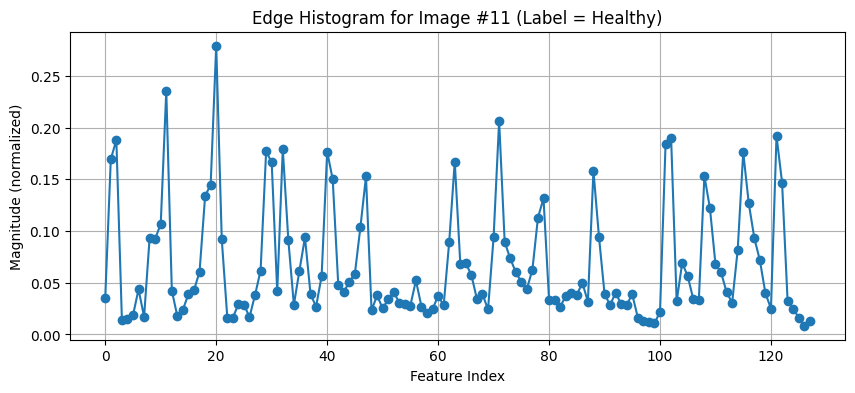

In [ ]:
#confirming the images of edge histogram.
id = 11  

hist = X[id]
print("Histogram shape:", hist.shape) 
print("First 15 values:", hist[:15])     

plt.figure(figsize=(10,4))
plt.plot(hist, marker='o')
plt.title(f"Edge Histogram for Image #{id} (Label = {labels[id]})")
plt.xlabel("Feature Index")
plt.ylabel("Magnitude (normalized)")
plt.grid(True)
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
import numpy as np
print("\nClass distribution in training set:")
print(np.unique(y_train, return_counts=True))
print("\nClass distribution in test set:")
print(np.unique(y_test, return_counts=True))


Training set size: 2200
Test set size: 550

Class distribution in training set:
(array(['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR'],
      dtype='<U14'), array([800, 296, 720, 232, 152]))

Class distribution in test set:
(array(['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR'],
      dtype='<U14'), array([200,  74, 180,  58,  38]))


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
print("Standardization complete.")
print("Mean of training set (first 5 features):", scaler.mean_[:5])
print("Std of training set (first 5 features):", scaler.scale_[:5])

Standardization complete.
Mean of training set (first 5 features): [0.12675975 0.17993807 0.06469937 0.01846091 0.02069513]
Std of training set (first 5 features): [0.08156646 0.06112723 0.07042812 0.01160572 0.01362175]


In [13]:
X_test_std


array([[ 1.1363854 ,  0.89442366, -0.5228217 , ...,  0.6595249 ,
         0.11106047, -0.02577726],
       [-1.1946977 , -0.1922399 ,  1.906614  , ..., -0.24808444,
         0.6637409 , -0.7367715 ],
       [ 0.7519275 ,  0.63338584, -0.27401048, ...,  0.41764998,
         0.7094606 ,  0.73763543],
       ...,
       [ 1.6089106 ,  0.767389  , -0.532638  , ...,  0.27020872,
         0.20691243, -0.08225232],
       [ 0.47146788, -0.13700266, -0.6657703 , ...,  1.1231875 ,
        -0.03524952,  0.42619476],
       [-1.258663  ,  0.3292591 ,  1.9941311 , ..., -0.56144506,
        -0.71307856, -0.8478593 ]], dtype=float32)

In [15]:
pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 3.6 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [17]:
models = {
    "Decision Tree (max_depth=10)": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Neural Network (MLP 10,10,10)": MLPClassifier(hidden_layer_sizes=(10,10,10), max_iter=500, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

=== 5-Fold Cross-Validation (Train Data) ===

Decision Tree (max_depth=10): Mean CV Accuracy = 0.5764  (Std = 0.0334)


/Users/samreddyvarunreddy/tensorflow-test/env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/samreddyvarunreddy/tensorflow-test/env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/samreddyvarunreddy/tensorflow-test/env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/samreddyvarunreddy/tensorflow-test/env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and 

Neural Network (MLP 10,10,10): Mean CV Accuracy = 0.5882  (Std = 0.0199)
AdaBoost: Mean CV Accuracy = 0.5641  (Std = 0.0111)

=== Test Set Evaluation ===

Decision Tree (max_depth=10): Test Accuracy = 0.5927, Macro F1 = 0.4277
                precision    recall  f1-score   support

       Healthy       0.83      0.88      0.85       200
       Mild DR       0.33      0.36      0.35        74
   Moderate DR       0.56      0.60      0.58       180
Proliferate DR       0.32      0.19      0.24        58
     Severe DR       0.14      0.11      0.12        38

      accuracy                           0.59       550
     macro avg       0.44      0.43      0.43       550
  weighted avg       0.57      0.59      0.58       550

------------------------------------------------------------


/Users/samreddyvarunreddy/tensorflow-test/env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network (MLP 10,10,10): Test Accuracy = 0.6109, Macro F1 = 0.4721
                precision    recall  f1-score   support

       Healthy       0.84      0.86      0.85       200
       Mild DR       0.50      0.41      0.45        74
   Moderate DR       0.58      0.61      0.59       180
Proliferate DR       0.27      0.28      0.27        58
     Severe DR       0.21      0.18      0.19        38

      accuracy                           0.61       550
     macro avg       0.48      0.47      0.47       550
  weighted avg       0.60      0.61      0.61       550

------------------------------------------------------------
AdaBoost: Test Accuracy = 0.5309, Macro F1 = 0.3538
                precision    recall  f1-score   support

       Healthy       0.85      0.85      0.85       200
       Mild DR       0.21      0.19      0.20        74
   Moderate DR       0.45      0.54      0.49       180
Proliferate DR       0.22      0.07      0.11        58
     Severe DR       0.12 

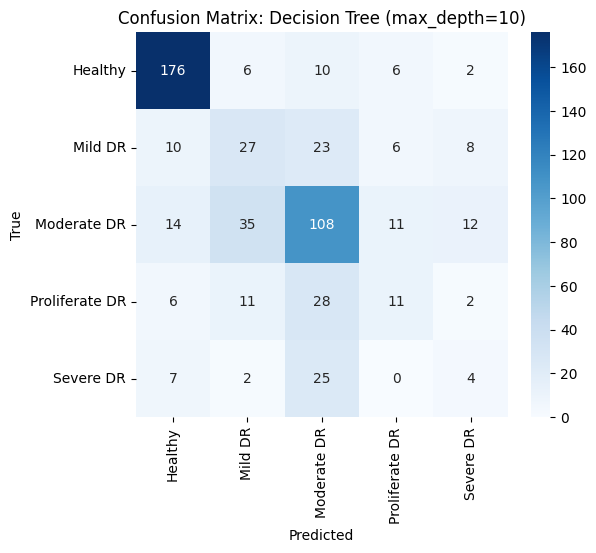

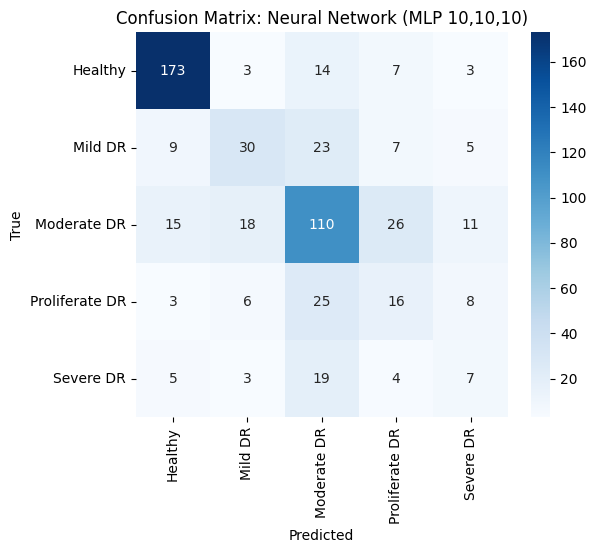

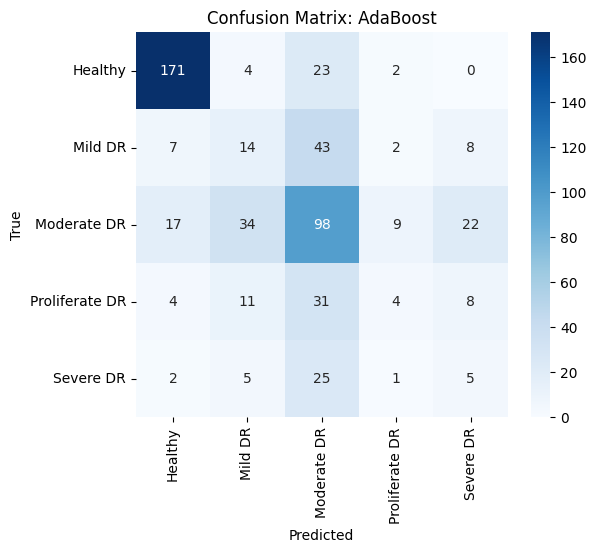

In [18]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== 5-Fold Cross-Validation (Train Data) ===\n")
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_std, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name}: Mean CV Accuracy = {scores.mean():.4f}  (Std = {scores.std():.4f})")

# Train and Test Evaluation
print("\n=== Test Set Evaluation ===\n")
test_results = {}

for name, model in models.items():
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    test_results[name] = (acc, f1, y_pred)

    print(f"{name}: Test Accuracy = {acc:.4f}, Macro F1 = {f1:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

# Plot confusion matrices
def plot_cm(cm, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

print("=== Confusion Matrices (Test Set) ===\n")

for name, (acc, f1, y_pred) in test_results.items():
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
    plot_cm(cm, f"Confusion Matrix: {name}")


In [19]:
# Question 7
two_classes = ["Healthy", "Mild DR"]
print("Using classes:", two_classes)

train_mask = np.isin(y_train, two_classes)
test_mask  = np.isin(y_test, two_classes)

Xtr2 = X_train_std[train_mask]
ytr2 = y_train[train_mask]
Xte2 = X_test_std[test_mask]
yte2 = y_test[test_mask]

label_map = {two_classes[0]:0, two_classes[1]:1}
ytr2 = np.array([label_map[v] for v in ytr2])
yte2 = np.array([label_map[v] for v in yte2])
print("Training size:", Xtr2.shape, "Test size:", Xte2.shape)

Using classes: ['Healthy', 'Mild DR']
Training size: (1096, 128) Test size: (274, 128)


In [22]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import KFold, StratifiedKFold

Cs = [0.1, 1, 10, 100]

std_train_err = []
std_val_err = []
strat_train_err = []
strat_val_err = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for C in Cs:
    tr_e, va_e = [], []
    for tr, va in kf.split(Xtr2):
        model = LinearSVC(C=C, dual="auto", max_iter=5000, random_state=42)
        model.fit(Xtr2[tr], ytr2[tr])
        tr_e.append(1 - model.score(Xtr2[tr], ytr2[tr]))
        va_e.append(1 - model.score(Xtr2[va], ytr2[va]))
    std_train_err.append(np.mean(tr_e))
    std_val_err.append(np.mean(va_e))
    tr_e, va_e = [], []
    for tr, va in skf.split(Xtr2, ytr2):
        model = LinearSVC(C=C, dual="auto", max_iter=5000, random_state=42)
        model.fit(Xtr2[tr], ytr2[tr])
        tr_e.append(1 - model.score(Xtr2[tr], ytr2[tr]))
        va_e.append(1 - model.score(Xtr2[va], ytr2[va]))
    strat_train_err.append(np.mean(tr_e))
    strat_val_err.append(np.mean(va_e))


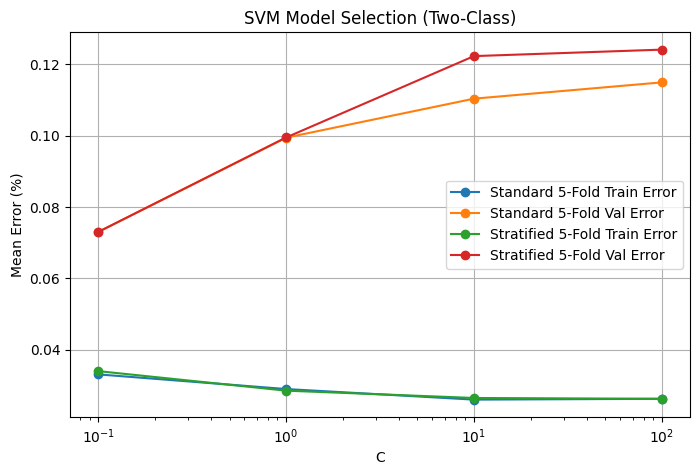

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(Cs, std_train_err, marker='o', label='Standard 5-Fold Train Error')
plt.plot(Cs, std_val_err, marker='o', label='Standard 5-Fold Val Error')
plt.plot(Cs, strat_train_err, marker='o', label='Stratified 5-Fold Train Error')
plt.plot(Cs, strat_val_err, marker='o', label='Stratified 5-Fold Val Error')

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean Error (%)")
plt.title("SVM Model Selection (Two-Class)")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
best_C = Cs[np.argmin(strat_val_err)]
print("Best C based on Stratified Validation Error:", best_C)

Best C based on Stratified Validation Error: 0.1


In [25]:
final_model = LinearSVC(C=best_C, random_state=42)
final_model.fit(Xtr2, ytr2)

test_accuracy = final_model.score(Xte2, yte2)
test_error = 1 - test_accuracy

print(f"Test Accuracy = {test_accuracy:.4f}")
print(f"Test Error = {test_error:.4f}")


Test Accuracy = 0.9197
Test Error = 0.0803


/Users/samreddyvarunreddy/tensorflow-test/env/lib/python3.10/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


By visually comparing (e.g., looking at the color on the diagonal values, etc.) the three confusion
matrices (on the test set), which do you think is the best method? Why? (0.50 point)

When comparing the confusion matrices visually, the Neural Network(MLP) shows the strongest diagonal patterns. So this means its classifies higher number of samples across the classes compared to other two Classification methods. The diagonal cells in the Neural Network's confusion matrix are darker, especially for Healthy, Mild DR, and Moderate DR, indicating better class discrimination.
Therefore, the Neural Network is the best method.

Based on the mean validation accuracies (from the 5-fold cross-validation) for the three methods.
Which is the best method? (0.25 point)

Based on the mean validation accuracies obtained from stratified 5-fold cross-validation, the Neural Network achieved the highest average validation accuracy, which is 0.5882 compared to the Decision Tree(0.5764) and AdaBoost(0.5641).
Therefore, the Neural Network is the best method according to cross-validation performance.

Compute the accuracies for the three methods on the test set. Which is the best method? (0.25
point)
Accuracies:
    Decision tree  0.5927
    AdaBoost       0.5309
    Neural Network 0.6109
So based on accuracy the Neural Network is the best fit model. 

Compute the F-measure for the three methods on the test set. Which is the best method? (0.25
point)

F-1 Scores:
    Decision tree  0.4277
    neural network 0.4721
    Adaboost       0.3538
So by comparing the F-1 score the neural network with highest F-1 score is the best  model.

#Question 7
Which 𝐶 has/have the lowest mean error for each curve? Comment about (1) the model
complexity for SVM in relation to 𝐶, and (2) when/whether there is overfitting/underfitting. (1.5
points)

1. The Stratified Validation Error Curve and the Standard Validation Error Curve has the lowest mean error value.

2. Model Complexity for SVM in relkation to C:
    The parameter C controls the margin hardness in the SVM.
    Small C value refers strong regularization, forcing a wider margin, which makes the classifier simpler but less flexible.
    Large C will reduces regularization, making the margin harder and narrower, increasing model complexity.
    Therefore, the increase in C value will increase model complexity.

3. Overfitting and underfitting: At C = 0.1, both training and validation errors were relatively high, indicating underfitting.
    At C = 100, the training error became very low, but validation error increased, indicating overfitting.
    At C = 1, validation error was minimized, indicating the best balance between margin complexity and generalization performance.

What is the error for the test dataset (i.e., the standardized edge histogram
dataset obtained from the test set)? (0.25 point)

Test Accuracy = 0.9197
(error = 1- accuracy)
Test Error = 0.0803